In [1]:
import numpy as np
import os
from scipy.io import loadmat, savemat
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks  

from tqdm.notebook import tqdm

# Load mean waveforms and cluster IDs from matlab
matlab_path = r"\\fsmresfiles.fsm.northwestern.edu\fsmresfiles\Basic_Sciences\Phys\SenzaiLab\Aparna\Mouse08\mean-waveforms-good-clusters"
mat_file = os.path.join(matlab_path, "meanWav_units.mat")

ksDir = r"D:\Kilosort\Mouse08_SC_20251007_810to2250\kilosort4"
chan_pos_file = os.path.join(ksDir, 'channel_positions.npy')

data = loadmat(mat_file)
meanWav = data['meanWav']          # nChannels x nSamples x nUnits
good_clusters = data['good_clusters'].squeeze()  # 1D array of cluster IDs

chan_pos = np.load(chan_pos_file)
xpos = chan_pos[:, 0]
ypos = chan_pos[:, 1]

nCh, nS, nUnits = meanWav.shape
num_channels_to_plot = 21  # number of channels around peak to include
spatialWindow = 300 # micrometers


In [2]:
# helper functions to calculate features for cell type differentiation

# features for UMAP: trough to peak latency, secondary trough size, number of phases (peaks), spatial spread (how many channels), propogation latency (depending on first channel)

def trough_to_peak_time(waveform, sr=30000):
    trough_idx = np.argmin(waveform)
    peak_idx = np.argmax(waveform[trough_idx:]) + trough_idx
    width_ms = (peak_idx - trough_idx) / sr * 1000
    return width_ms

def secondary_trough(waveform, sr=30000):
    troughs, _ = find_peaks(-waveform)
    troughs = troughs[troughs != np.argmin(waveform)]  # ignore main trough
    if len(troughs) > 0:
        return waveform[troughs[0]]  # first secondary trough
    else:
        return 0.0

def count_phases(waveform):
    zero_crossings = np.where(np.diff(np.sign(waveform)))[0]
    return len(zero_crossings)

def spatial_spread(neighborhood, threshold_ratio=0.2):
    peak_amp = np.max(np.ptp(neighborhood, axis=1))
    channels_active = np.sum(np.ptp(neighborhood, axis=1) > threshold_ratio*peak_amp)
    return channels_active

def propagation_latency(neighborhood, sr=30000):
    # latency of trough per channel relative to first channel
    troughs = np.argmin(neighborhood, axis=1)
    latency_ms = (troughs - troughs[0]) / sr * 1000
    return np.ptp(latency_ms)  # max-min latency across channels

In [3]:
# Extract features and build feature_list and channels_used_list based on neighboring channels

feature_list = []
channels_used_list = []

for u in range(nUnits):
    unit_wav = meanWav[:, :, u]

    # --- peak channel ---
    peak_ch = np.argmax(np.ptp(unit_wav, axis=1))
    peak_x = xpos[peak_ch]
    peak_y = ypos[peak_ch]

    # --- same shank ---
    same_shank = np.where(xpos == peak_x)[0]

    # --- parity filter ---
    peak_parity = peak_ch % 2
    same_parity = same_shank[same_shank % 2 == peak_parity]

    # --- distance filter ---
    y_distance = np.abs(ypos[same_parity] - peak_y)
    nearby_idx = np.where(y_distance <= spatialWindow)[0]
    channels_to_use = same_parity[nearby_idx]

    # expand if too few
    if len(channels_to_use) < num_channels_to_plot:
        sorted_idx = np.argsort(y_distance)
        n_take = min(num_channels_to_plot, len(same_parity))
        channels_to_use = same_parity[sorted_idx[:n_take]]

    # trim if too many
    if len(channels_to_use) > num_channels_to_plot:
        distances = np.abs(ypos[channels_to_use] - peak_y)
        sorted_idx = np.argsort(distances)
        channels_to_use = channels_to_use[sorted_idx[:num_channels_to_plot]]

    # sort by depth descending
    channels_to_use = channels_to_use[np.argsort(ypos[channels_to_use])[::-1]]
    channels_used_list.append(channels_to_use)

    neighborhood = unit_wav[channels_to_use, :]
    peak_wave = unit_wav[peak_ch, :]

    # temporal features
    ptp_width = trough_to_peak_time(peak_wave)
    main_trough = np.min(peak_wave)
    main_peak = np.max(peak_wave)
    sec_trough = secondary_trough(peak_wave)
    phases = count_phases(peak_wave)

    # spatial features
    spread = spatial_spread(neighborhood)
    prop_latency = propagation_latency(neighborhood)

    # PCA features
    pca = PCA(n_components=3)
    pca_scores = pca.fit_transform(neighborhood.T).flatten()

    features = [ptp_width, main_peak, main_trough, sec_trough, phases,
                spread, prop_latency] + list(pca_scores)
    feature_list.append(features)

features_array = np.array(feature_list)

# Standardize features
X_scaled = StandardScaler().fit_transform(features_array)

In [4]:
# Create UMAP and cluster
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=2, random_state=42)
cluster_ids = kmeans.fit_predict(X_umap)

ptp_widths = features_array[:, 0]
spreads = features_array[:, 5]

# compute cluster means
cluster_scores = []
for cluster_id in np.unique(cluster_ids):
    mask = cluster_ids == cluster_id
    score = np.mean(ptp_widths[mask]) - np.mean(spreads[mask])
    cluster_scores.append(score)

if cluster_scores[0] < cluster_scores[1]:
    RGC_cluster = 0
    SC_cluster = 1
else:
    RGC_cluster = 1
    SC_cluster = 0


# thresholds for "unsure"
ptp_thresh = 0.1 * abs(np.mean(ptp_widths[cluster_ids==RGC_cluster]) - np.mean(ptp_widths[cluster_ids==SC_cluster]))
spread_thresh = 0.1 * abs(np.mean(spreads[cluster_ids==RGC_cluster]) - np.mean(spreads[cluster_ids==SC_cluster]))

unit_labels = []
for i in range(nUnits):
    width = ptp_widths[i]
    spread = spreads[i]
    width_close = (abs(width - np.mean(ptp_widths[cluster_ids==RGC_cluster])) < ptp_thresh) or \
                  (abs(width - np.mean(ptp_widths[cluster_ids==SC_cluster])) < ptp_thresh)
    spread_close = (abs(spread - np.mean(spreads[cluster_ids==RGC_cluster])) < spread_thresh) or \
                   (abs(spread - np.mean(spreads[cluster_ids==SC_cluster])) < spread_thresh)
    if width_close and spread_close:
        unit_labels.append("unsure")
    elif cluster_ids[i] == RGC_cluster:
        unit_labels.append("RGC")
    else:
        unit_labels.append("SC")

unit_labels = np.array(unit_labels)



c:\Users\urs2027\AppData\Local\Programs\Python\Python314\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [13]:
# ---- Build per-unit classification table ----

classification_table = []

for i in range(nUnits):
    classification_table.append((
        int(good_clusters[i]),     # original Kilosort cluster ID
        int(cluster_ids[i]),       # KMeans cluster number
        unit_labels[i]             # "RGC", "SC", or "unsure"
    ))

classification_array = np.array(classification_table, dtype=object)


In [ ]:
# Save files to mat
save_folder = r"\\fsmresfiles.fsm.northwestern.edu\fsmresfiles\Basic_Sciences\Phys\SenzaiLab\Aparna\Mouse08\SC-RGC-classification-with-umap"

save_path = os.path.join(save_folder, "SC_RGC_classification.mat")

save_dict = {
    # 'unit_labels': unit_labels,
    # 'cluster_ids': cluster_ids,
    'features_array': features_array,
    # 'good_clusters': good_clusters,
    'channels_used': np.array(channels_used_list, dtype=object),
    'classification_table': classification_array
}

savemat(save_path, save_dict)
print("Saved features, cluster IDs, and labels to SC_RGC_classification.mat")

Saved features, cluster IDs, and labels to SC_RGC_classification.mat


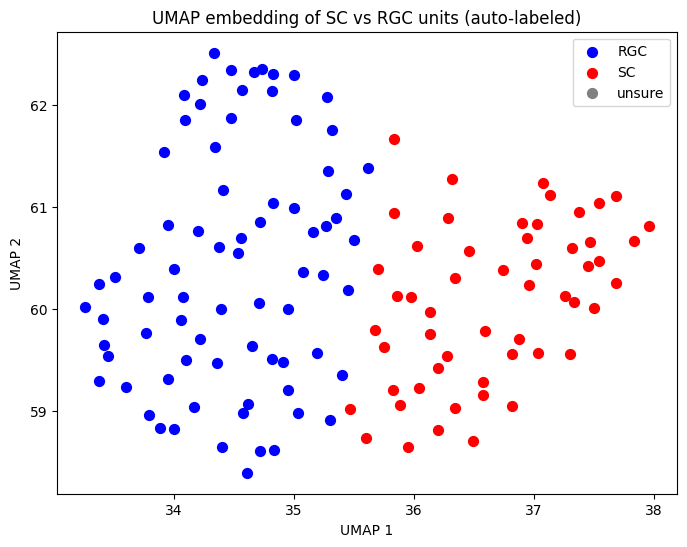

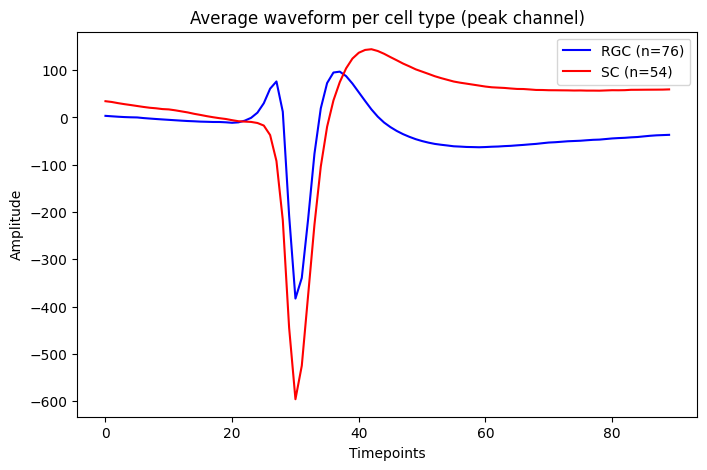

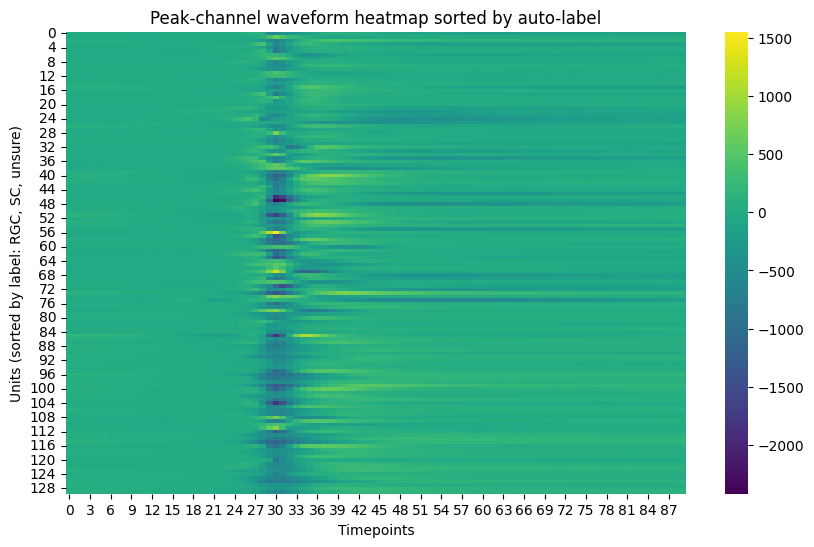

In [6]:
# plot umap with labels

colors = {'RGC': 'blue', 'SC': 'red', 'unsure': 'gray'}

# --- UMAP embedding ---
plt.figure(figsize=(8,6))
for cell_type in ['RGC','SC','unsure']:
    mask = unit_labels == cell_type
    plt.scatter(X_umap[mask,0], X_umap[mask,1], label=cell_type, s=50, c=colors[cell_type])
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP embedding of SC vs RGC units (auto-labeled)')
plt.legend()
plt.show()

# --- Average waveform per cluster (peak channel) ---
plt.figure(figsize=(8,5))
for cell_type in ['RGC','SC','unsure']:
    units_idx = np.where(unit_labels == cell_type)[0]
    if len(units_idx) == 0:
        continue
    avg_peak_wave = np.mean([meanWav[np.argmax(np.ptp(meanWav[:,:,i], axis=1)), :, i] for i in units_idx], axis=0)
    plt.plot(avg_peak_wave, label=f'{cell_type} (n={len(units_idx)})', color=colors[cell_type])
plt.xlabel('Timepoints')
plt.ylabel('Amplitude')
plt.title('Average waveform per cell type (peak channel)')
plt.legend()
plt.show()

# --- Heatmap of peak-channel waveforms sorted by label ---
plt.figure(figsize=(10,6))
sorted_idx = np.argsort([{'RGC':0, 'SC':1, 'unsure':2}[lbl] for lbl in unit_labels])
heatmap_data = np.array([meanWav[np.argmax(np.ptp(meanWav[:,:,i], axis=1)), :, i] for i in sorted_idx])
sns.heatmap(heatmap_data, cmap='viridis')
plt.xlabel('Timepoints')
plt.ylabel('Units (sorted by label: RGC, SC, unsure)')
plt.title('Peak-channel waveform heatmap sorted by auto-label')
plt.show()

# --- Optional: overlay propagation heatmaps for unsure units ---
for u in range(nUnits):
    if unit_labels[u] != 'unsure':
        continue
    neighborhood = meanWav[channels_used_list[u], :, u]
    plt.figure(figsize=(8,4))
    sns.heatmap(neighborhood, cmap='jet', cbar=True)
    plt.title(f'Unit {good_clusters[u]}: unsure propagation heatmap')
    plt.xlabel('Timepoints')
    plt.ylabel('Channels (MATLAB-style neighborhood)')
    plt.show()


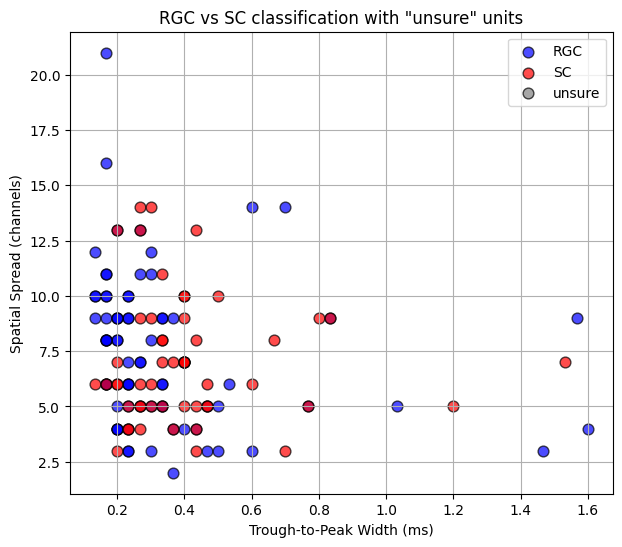

In [7]:
import matplotlib.pyplot as plt

# Extract features used for labeling
ptp_widths = features_array[:, 0]  # trough-to-peak width
spreads = features_array[:, 5]     # spatial spread

# Plot
plt.figure(figsize=(7,6))
colors = {'RGC':'blue', 'SC':'red', 'unsure':'gray'}

for label in ['RGC','SC','unsure']:
    mask = unit_labels == label
    plt.scatter(ptp_widths[mask], spreads[mask], 
                c=colors[label], label=label, s=60, alpha=0.7, edgecolor='k')

plt.xlabel('Trough-to-Peak Width (ms)')
plt.ylabel('Spatial Spread (channels)')
plt.title('RGC vs SC classification with "unsure" units')
plt.legend()
plt.grid(True)
plt.show()


In [8]:
# Make summary table that has which unit id is rgc vs sc

import pandas as pd

# Prepare the data
summary_data = []

for label in ['RGC', 'SC', 'unsure']:
    mask = unit_labels == label
    units = good_clusters[mask]
    summary_data.append({
        'Label': label,
        'Num_Units': len(units),
        'Unit_IDs': ', '.join(map(str, units))  # as comma-separated string
    })

# Create DataFrame
summary_df = pd.DataFrame(summary_data)

# Display table
print(summary_df)

# Optional: save to CSV in the same folder as your .mat file
# csv_path = os.path.join(save_folder, 'SC_RGC_summary.csv')
# summary_df.to_csv(csv_path, index=False)
# print(f"Summary table saved to: {csv_path}")


    Label  Num_Units                                           Unit_IDs
0     RGC         76  2, 3, 11, 12, 13, 17, 18, 23, 24, 28, 41, 58, ...
1      SC         54  27, 89, 96, 147, 149, 216, 253, 274, 359, 376,...
2  unsure          0                                                   


Text(0.5, 1.0, 'Spatial spread')

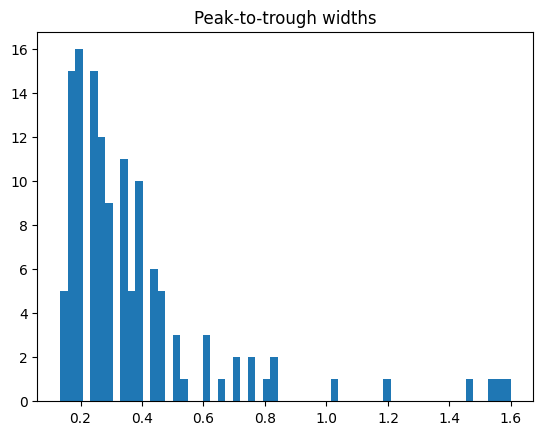

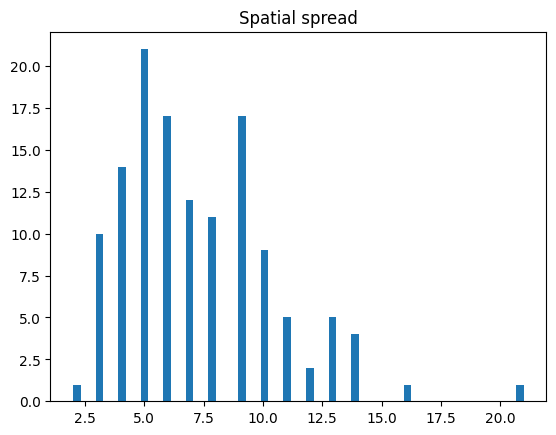

In [9]:
# test code to see if there are two modes of features
plt.figure()
plt.hist(ptp_widths, bins=60)
plt.title("Peak-to-trough widths")

plt.figure()
plt.hist(spreads, bins=60)
plt.title("Spatial spread")


In [10]:
from sklearn.metrics import silhouette_score, silhouette_samples

score = silhouette_score(X_scaled, cluster_ids)
print("Silhouette score:", score)


Silhouette score: 0.08368799090515844


Text(0, 0.5, 'Spatial spread')

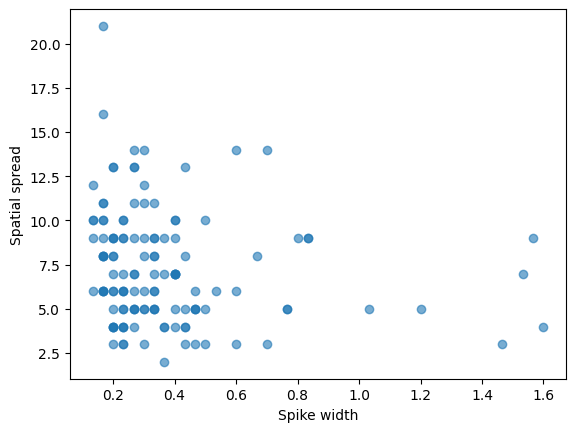

In [11]:
plt.scatter(ptp_widths, spreads, alpha=0.6)
plt.xlabel("Spike width")
plt.ylabel("Spatial spread")

In [12]:
for k in [2,3,4]:
    km = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    score = silhouette_score(X_scaled, km.labels_)
    print(f"k={k}, silhouette={score:.3f}")

k=2, silhouette=0.340
k=3, silhouette=0.208
k=4, silhouette=0.233
